In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 │ ⚙️ CONFIG + LOAD DATASET (ViQuAD 2.0 validation — from HuggingFace)
# ─────────────────────────────────────────────────────────────────────────────

import os
import re
import sys
import json
import random
from pathlib import Path
from datetime import datetime
from datasets import load_dataset

# ── CONFIG ────────────────────────────────────────────────────────────────────
MODEL_NAME        = "/home/rtx5070tiadmin/FPT_Exam_Product_Support/Exam_AssistAI/qwen3_examassist_merged_4b_domain"
DATASET_PATH      = "taidng/UIT-ViQuAD2.0"
DATASET_N_SAMPLES = None        # None = use full dataset; set an integer (e.g. 200) for quick testing
RANDOM_SEED       = 42
MAX_NEW_TOKENS    = 128
TEMPERATURE       = 0.0
BATCH_SIZE        = 8
MAX_MODEL_LEN     = 2048
GPU_MEM_UTIL      = 0.80
RUN_NAME = "qwen3_vl_4b_finetuned(on_domain)_viquad_val"
OUTPUT_DIR = Path(f"./benchmark_outputs/{RUN_NAME}_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

# ── System prompt (aligned with fine-tuning distribution) ────────────────────
SYSTEM_PROMPT = (
    "Bạn là trợ lý hỗ trợ giám thị thi tại Đại học FPT. "
    "Chỉ trả lời dựa trên ngữ cảnh được cung cấp. "
    "Nếu không tìm thấy thông tin trong tài liệu, hãy trả lời: "
    "'Tôi không tìm thấy thông tin trong tài liệu'."
)

# ── Helpers (reused in Cell 3 / Cell 4) ──────────────────────────────────────
def build_user_message(context: str, question: str) -> str:
    return f"Ngữ cảnh: {context}\n\nCâu hỏi: {question}"

def extract_context_question(user_content):
    user_content = str(user_content).strip()
    context_match = re.search(
        r"(?:Context|Ngữ cảnh)\s*:\s*(.*?)\s*(?:Question|Câu hỏi)\s*:",
        user_content, flags=re.DOTALL | re.IGNORECASE
    )
    question_match = re.search(
        r"(?:Question|Câu hỏi)\s*:\s*(.*)",
        user_content, flags=re.DOTALL | re.IGNORECASE
    )
    context  = context_match.group(1).strip() if context_match else ""
    question = question_match.group(1).strip() if question_match else ""
    return context, question

# ── Load raw dataset ──────────────────────────────────────────────────────────
print(f"Downloading {DATASET_PATH} from HuggingFace...")
try:
    raw_dataset = load_dataset(DATASET_PATH, split="validation")
    print(f"✅ Successfully loaded: {len(raw_dataset)} samples (validation split)")
    print(f"   Columns: {raw_dataset.column_names}")
except Exception as e:
    print(f"❌ Failed to load dataset from HuggingFace: {e}")
    print("💡 Tip: Check your internet connection and try again.")
    sys.exit(1)

# ── Preprocess + build samples ────────────────────────────────────────────────
REFUSAL_GOLD = "tôi không tìm thấy thông tin trong tài liệu"

def preprocess_viquad(dataset, n_samples=None, seed=42):
    """
    Normalize UIT-ViQuAD2.0 into a list[dict] ready for inference.
    - Keeps both answerable and unanswerable samples (is_impossible=True).
    - Unanswerable → gold_answer = REFUSAL_GOLD so Cell 4 handles them uniformly.
    - Pre-builds messages (system + user) so Cell 3 can use them directly.
    """
    samples = []

    for item in dataset:
        ctx = item["context"].strip()
        q   = item["question"].strip()
        if not ctx or not q:
            continue

        is_impossible = item.get("is_impossible", False)

        if is_impossible:
            gold_answers = [REFUSAL_GOLD]
        else:
            ans_field = item["answers"]
            if isinstance(ans_field, dict):
                ans_texts = [a.strip() for a in ans_field.get("text", []) if str(a).strip()]
            else:
                ans_texts = [str(ans_field).strip()]

            if not ans_texts:
                continue  # answerable but missing label — skip

            gold_answers = ans_texts

        user_msg = build_user_message(ctx, q)

        samples.append({
            "id":           item["id"],
            "context":      ctx,
            "question":     q,
            "gold_answers": gold_answers,
            "gold_answer":  gold_answers[0],    # used by Cell 4
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": user_msg}
            ]
        })

    if n_samples and len(samples) > n_samples:
        random.seed(seed)
        samples = random.sample(samples, n_samples)

    answerable_count   = sum(1 for s in samples if s["gold_answer"] != REFUSAL_GOLD)
    unanswerable_count = len(samples) - answerable_count
    print(f"✅ Total samples: {len(samples)} "
          f"(answerable: {answerable_count}, unanswerable: {unanswerable_count})")
    return samples


samples = preprocess_viquad(raw_dataset, n_samples=DATASET_N_SAMPLES, seed=RANDOM_SEED)

# ── Preview ───────────────────────────────────────────────────────────────────
print("\n📋 Preview — first 3 samples:")
for i, s in enumerate(samples[:3]):
    print(f"\n[{i+1}] ID           : {s['id']}")
    print(f"    Question     : {s['question']}")
    print(f"    Gold answer  : {s['gold_answers']}")
    print(f"    Context      : {s['context'][:100]}...")

/home/rtx5070tiadmin/FPT_Exam_Product_Support/Exam_AssistAI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OUTPUT_DIR: /home/rtx5070tiadmin/FPT_Exam_Product_Support/Exam_AssistAI/benchmark_outputs/qwen3_vl_4b_finetuned(on_domain)_viquad_val_20260620_222541
✅ Successfully loaded: 3814 samples (validation split)
   Columns: ['id', 'uit_id', 'title', 'context', 'question', 'answers', 'is_impossible', 'plausible_answers']
✅ Total samples: 3814 (answerable: 2653, unanswerable: 1161)

📋 Preview — first 3 samples:

[1] ID           : 0001-0001-0001
    Question     : Paris đạt được thành quả gì sau khoảng 4 thế kỷ tính từ ngày Cách mạng Pháp diễn ra?
    Gold answer  : ['trở thành một trong những trung tâm văn hóa của thế giới, thủ đô của nghệ thuật và giải trí']
    Context      : Paris nằm ở điểm gặp nhau của các hành trình thương mại đường bộ và đường sông, và là trung tâm của ...

[2] ID           : 0001-0001-0002
    Question     : Vị trí địa lý của Pháp có gì đặc biệt?
    Gold answer  : ['tôi không tìm thấy thông tin trong tài liệu']
    Context      : Paris nằm ở điểm gặp nhau của các hành

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 │ 🚀 LOAD QWEN3-VL-4B-INSTRUCT WITH vLLM
# ─────────────────────────────────────────────────────────────────────────────
import io
import sys
import os
import subprocess
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams

def _patch_jupyter_streams():
    _null_fd = os.open(os.devnull, os.O_WRONLY)

    class _FilenoPatchedStream:
        def __init__(self, original, null_fd):
            object.__setattr__(self, "_orig", original)
            object.__setattr__(self, "_null_fd", null_fd)

        def fileno(self):
            return object.__getattribute__(self, "_null_fd")

        def write(self, s):
            return object.__getattribute__(self, "_orig").write(s)

        def flush(self):
            return object.__getattribute__(self, "_orig").flush()

        def isatty(self):
            return False

        def readable(self):
            return False

        def writable(self):
            return True

        def __getattr__(self, name):
            return getattr(object.__getattribute__(self, "_orig"), name)

    for stream_name in ("stdout", "stderr"):
        stream = getattr(sys, stream_name)
        try:
            stream.fileno()
        except io.UnsupportedOperation:
            setattr(sys, stream_name, _FilenoPatchedStream(stream, _null_fd))

_patch_jupyter_streams()

print(subprocess.getoutput("nvidia-smi"))

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

llm = LLM(
    model=MODEL_NAME,
    trust_remote_code=True,
    dtype="half",
    quantization=None,
    max_model_len=MAX_MODEL_LEN,
    gpu_memory_utilization=GPU_MEM_UTIL,
    enforce_eager=True,
    max_num_seqs=BATCH_SIZE,
    limit_mm_per_prompt={"image": 0}
)

sampling_params = SamplingParams(
    temperature=TEMPERATURE,
    max_tokens=MAX_NEW_TOKENS
)

print("✅ Model loaded successfully.")

Sat Jun 20 22:25:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti     Off |   00000000:02:00.0  On |                  N/A |
|  0%   42C    P5             38W /  300W |    2514MiB /  16303MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

[transformers] `Qwen2VLImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Qwen2VLImageProcessor` instead.
[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


(EngineCore pid=855461) INFO 06-20 22:25:53 [core.py:112] Initializing a V1 LLM engine (v0.22.0) with config: model='/home/rtx5070tiadmin/FPT_Exam_Product_Support/Exam_AssistAI/qwen3_examassist_merged_4b_domain', speculative_config=None, tokenizer='/home/rtx5070tiadmin/FPT_Exam_Product_Support/Exam_AssistAI/qwen3_examassist_merged_4b_domain', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, quantization_config=None, enforce_eager=True, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:02<00:00,  2.19s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:02<00:00,  2.19s/it]
(EngineCore pid=855461) 


(EngineCore pid=855461) INFO 06-20 22:25:56 [default_loader.py:397] Loading weights took 2.29 seconds
(EngineCore pid=855461) INFO 06-20 22:25:57 [gpu_model_runner.py:5132] Model loading took 8.69 GiB memory and 2.490487 seconds
(EngineCore pid=855461) INFO 06-20 22:25:57 [gpu_model_runner.py:6136] Encoder cache will be initialized with a budget of 12288 tokens, and profiled with 1 video items of the maximum feature size.
(EngineCore pid=855461) INFO 06-20 22:26:02 [gpu_worker.py:466] Available KV cache memory: 2.18 GiB
(EngineCore pid=855461) INFO 06-20 22:26:02 [kv_cache_utils.py:1733] GPU KV cache size: 15,856 tokens
(EngineCore pid=855461) INFO 06-20 22:26:02 [kv_cache_utils.py:1734] Maximum concurrency for 2,048 tokens per request: 7.74x


(EngineCore pid=855461) 2026-06-20 22:26:02,244 - INFO - autotuner.py:615 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=855461) 2026-06-20 22:26:02,259 - INFO - autotuner.py:634 - flashinfer.jit: [Autotuner]: Autotuning process ends


(EngineCore pid=855461) INFO 06-20 22:26:02 [jit_monitor.py:54] Kernel JIT monitor activated — Triton JIT compilations during inference will be logged as warnings.
(EngineCore pid=855461) INFO 06-20 22:26:02 [core.py:309] init engine (profile, create kv cache, warmup model) took 5.78 s
(EngineCore pid=855461) WARNING 06-20 22:26:03 [vllm.py:1033] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
(EngineCore pid=855461) WARNING 06-20 22:26:03 [vllm.py:1058] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
(EngineCore pid=855461) INFO 06-20 22:26:03 [kernel.py:270] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=['vllm_c', 'native'])
(EngineCore pid=855461) INFO 06-20 22:26:03 [vllm.py:1234] Cudagraph is disabled under eager mode
✅ Model loaded suc

(EngineCore pid=855461) WARNING 06-20 22:26:03 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _compute_slot_mapping_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=855461) WARNING 06-20 22:28:48 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _triton_mrope_forward. This causes a latency spike; consider extending warmup to cover this shape/config.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 │ 🔮 INFERENCE
# ─────────────────────────────────────────────────────────────────────────────
import time
from tqdm import tqdm

prompts = []

for s in samples:
    prompt = tokenizer.apply_chat_template(
        s["messages"],
        tokenize=False,
        add_generation_prompt=True
    )
    prompts.append(prompt)

print("Total prompts:", len(prompts))
print("Prompt preview:")
print(prompts[0][:1000])

start_time = time.time()

outputs = llm.generate(
    prompts,
    sampling_params,
    use_tqdm=True
)

total_time = time.time() - start_time

predictions = [
    output.outputs[0].text.strip()
    for output in outputs
]

for s, pred in zip(samples, predictions):
    s["prediction"] = pred

print("✅ Inference completed")
print("Total time:", round(total_time, 2), "seconds")
print("Avg latency:", round(total_time / len(samples), 4), "sec/sample")
print("Throughput:", round(len(samples) / total_time, 2), "samples/sec")

print("\nPrediction example:")
print(predictions[0])

Total prompts: 3814
Prompt preview:
<|im_start|>system
Bạn là trợ lý hỗ trợ giám thị thi tại Đại học FPT. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Nếu không tìm thấy thông tin trong tài liệu, hãy trả lời: 'Tôi không tìm thấy thông tin trong tài liệu'.<|im_end|>
<|im_start|>user
Ngữ cảnh: Paris nằm ở điểm gặp nhau của các hành trình thương mại đường bộ và đường sông, và là trung tâm của một vùng nông nghiệp giàu có. Vào thế kỷ 10, Paris đã là một trong những thành phố chính của Pháp cùng các cung điện hoàng gia, các tu viện và nhà thờ. Từ thế kỷ 12, Paris trở thành một trong những trung tâm của châu Âu về giáo dục và nghệ thuật. Thế kỷ 14, Paris là thành phố quan trọng bậc nhất của Cơ Đốc giáo và trong các thế kỷ 16, 17, đây là nơi diễn ra Cách mạng Pháp cùng nhiều sự kiện lịch sử quan trọng của Pháp và châu Âu. Đến thế kỷ 19 và 20, thành phố trở thành một trong những trung tâm văn hóa của thế giới, thủ đô của nghệ thuật và giải trí.

Câu hỏi: Paris đạt được thành quả gì sau khoảng 

Processed prompts: 100%|██████████| 3814/3814 [02:43<00:00, 23.33it/s, est. speed input: 7554.25 toks/s, output: 513.04 toks/s] 

✅ Inference completed
Total time: 164.97 seconds
Avg latency: 0.0433 sec/sample
Throughput: 23.12 samples/sec

Prediction example:
Paris trở thành một trong những trung tâm văn hóa của thế giới, thủ đô của nghệ thuật và giải trí.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 │ 📊 EVALUATION METRICS — ANSWERABLE / UNANSWERABLE + FAITHFULNESS
#             + CONTEXT RECALL
# ─────────────────────────────────────────────────────────────────────────────

import re
import json
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter

REFUSAL_GOLD = "tôi không tìm thấy thông tin trong tài liệu"

REFUSAL_PATTERNS = [
    "tôi không tìm thấy thông tin",
    "không tìm thấy thông tin",
    "không có thông tin",
    "không được cung cấp",
    "không có trong ngữ cảnh",
    "không có trong tài liệu",
    "không thể trả lời",
    "không đủ thông tin"
]

# ── Text utilities ────────────────────────────────────────────────────────────

def normalize_text(text):
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(
        r"[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]",
        " ", text
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_gold_unanswerable(gold):
    return REFUSAL_GOLD in normalize_text(gold)

def is_pred_refusal(pred):
    pred_norm = normalize_text(pred)
    return any(p in pred_norm for p in REFUSAL_PATTERNS)

# ── Standard QA metrics ───────────────────────────────────────────────────────

def compute_em(pred, gold):
    return int(normalize_text(pred) == normalize_text(gold))

def compute_f1(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def lcs_length(x, y):
    dp = [[0] * (len(y) + 1) for _ in range(len(x) + 1)]
    for i in range(1, len(x) + 1):
        for j in range(1, len(y) + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[-1][-1]

def compute_rouge_l(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    lcs = lcs_length(pred_tokens, gold_tokens)
    precision = lcs / len(pred_tokens)
    recall    = lcs / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def compute_containment(pred, gold):
    pred_norm = normalize_text(pred)
    gold_norm = normalize_text(gold)
    if not gold_norm:
        return 0
    return int(gold_norm in pred_norm)

# ── Faithfulness ─────────────────────────────────────────────────────────────
# Định nghĩa: prediction phải "có căn cứ" trong context.
# Approximation không dùng LLM judge:
#   - Token-level precision của prediction so với context.
#   - faithfulness = |tokens(pred) ∩ tokens(context)| / |tokens(pred)|
#   - Đối với unanswerable: nếu model từ chối đúng → 1.0 (không hallucinate),
#     nếu model hallucinate → đo bình thường (thường rất thấp).

def compute_faithfulness(pred: str, context: str) -> float:
    """
    Token-level precision: tỷ lệ token trong prediction xuất hiện trong context.
    Cao → prediction bám sát context (faithful).
    Thấp → prediction chứa nhiều nội dung không có trong context (hallucination).
    """
    pred_tokens    = normalize_text(pred).split()
    context_tokens = set(normalize_text(context).split())
    if not pred_tokens:
        return 1.0   # empty pred không thêm thông tin sai
    matched = sum(1 for t in pred_tokens if t in context_tokens)
    return matched / len(pred_tokens)

# ── Context Recall ────────────────────────────────────────────────────────────
# Định nghĩa: gold answer phải được "bao phủ" bởi context.
# Approximation: token-level recall của gold so với context.
#   context_recall = |tokens(gold) ∩ tokens(context)| / |tokens(gold)|
# Nếu gold_unanswerable → context_recall = 1.0
#   (context đúng khi KHÔNG chứa câu trả lời, và mô hình nên từ chối)

def compute_context_recall(gold: str, context: str, gold_unanswerable: bool) -> float:
    """
    Đo mức độ context hỗ trợ gold answer.
    Với unanswerable: luôn = 1.0 vì context đúng là thiếu thông tin.
    """
    if gold_unanswerable:
        return 1.0
    gold_tokens    = normalize_text(gold).split()
    context_tokens = set(normalize_text(context).split())
    if not gold_tokens:
        return 1.0
    matched = sum(1 for t in gold_tokens if t in context_tokens)
    return matched / len(gold_tokens)

# ── Main evaluation loop ──────────────────────────────────────────────────────

# ── Main evaluation loop (FIX #3: max score across all gold_answers) ─────────

rows = []

for s in samples:
    pred             = s["prediction"]
    gold             = s["gold_answer"]         # primary reference
    gold_answers_all = s.get("gold_answers", [gold])  # full list
    context          = s.get("context", "")
    is_impossible    = s.get("is_impossible", False)

    gold_unanswerable = is_impossible
    pred_refusal      = is_pred_refusal(pred)
    answerable        = not gold_unanswerable

    faithfulness   = compute_faithfulness(pred, context)
    context_recall = compute_context_recall(gold, context, gold_unanswerable)

    if answerable:
        # FIX #3: take max score across all reference answers
        em          = max(compute_em(pred, g)      for g in gold_answers_all)
        f1          = max(compute_f1(pred, g)      for g in gold_answers_all)
        rouge_l     = max(compute_rouge_l(pred, g) for g in gold_answers_all)
        containment = max(compute_containment(pred, g) for g in gold_answers_all)

        false_refusal   = int(pred_refusal)
        correct_refusal = 0
        hallucination   = 0

    else:
        em      = int(pred_refusal)
        f1      = 1.0 if pred_refusal else 0.0
        rouge_l = 1.0 if pred_refusal else 0.0
        containment = 0

        false_refusal   = 0
        correct_refusal = int(pred_refusal)
        hallucination   = int(not pred_refusal)

    rows.append({
        "id":          s["id"],
        "question":    s["question"],
        "context":     context,
        "gold_answer": gold,
        "gold_answers_all": json.dumps(gold_answers_all, ensure_ascii=False),
        "prediction":  pred,

        "is_answerable":   int(answerable),
        "is_unanswerable": int(not answerable),
        "pred_refusal":    int(pred_refusal),

        "em":          em,
        "f1":          f1,
        "rouge_l":     rouge_l,
        "containment": containment,

        "faithfulness":   faithfulness,
        "context_recall": context_recall,

        "false_refusal":   false_refusal,
        "correct_refusal": correct_refusal,
        "hallucination":   hallucination,

        "gold_len_words": len(gold.split()),
        "pred_len_words": len(pred.split())
    })

# ... phần summary và display giữ nguyên từ Cell 4 trước
df = pd.DataFrame(rows)

answerable_df   = df[df["is_answerable"]   == 1]
unanswerable_df = df[df["is_unanswerable"] == 1]

summary = {
    "model":   MODEL_NAME,
    "dataset": DATASET_PATH,
    "num_samples": len(df),

    "answerable_samples":   len(answerable_df),
    "unanswerable_samples": len(unanswerable_df),

    "overall_em":      df["em"].mean()      * 100,
    "overall_f1":      df["f1"].mean()      * 100,
    "overall_rouge_l": df["rouge_l"].mean() * 100,

    "answerable_em":           answerable_df["em"].mean()          * 100,
    "answerable_f1":           answerable_df["f1"].mean()          * 100,
    "answerable_rouge_l":      answerable_df["rouge_l"].mean()     * 100,
    "answerable_containment":  answerable_df["containment"].mean() * 100,
    "false_refusal_rate_answerable": answerable_df["false_refusal"].mean() * 100,

    "correct_refusal_rate_unanswerable": unanswerable_df["correct_refusal"].mean() * 100,
    "hallucination_rate_unanswerable":   unanswerable_df["hallucination"].mean()   * 100,

    # ── New ───────────────────────────────────────────────────────────────
    "overall_faithfulness":          df["faithfulness"].mean()   * 100,
    "answerable_faithfulness":       answerable_df["faithfulness"].mean()   * 100,
    "unanswerable_faithfulness":     unanswerable_df["faithfulness"].mean() * 100,

    "overall_context_recall":        df["context_recall"].mean()  * 100,
    "answerable_context_recall":     answerable_df["context_recall"].mean()  * 100,
    # unanswerable context_recall luôn = 100% theo định nghĩa, vẫn log để minh bạch
    "unanswerable_context_recall":   unanswerable_df["context_recall"].mean() * 100,

    "avg_gold_len_words": df["gold_len_words"].mean(),
    "avg_pred_len_words": df["pred_len_words"].mean(),

    "total_inference_time_sec": total_time,
    "avg_latency_sec":          total_time / max(len(df), 1),
    "throughput_samples_per_sec": len(df) / total_time if total_time > 0 else 0
}

summary_df = pd.DataFrame([summary])

print("===== BENCHMARK SUMMARY — SQUAD2 / VIQUAD2 STYLE =====")
display(summary_df)

print("\n===== KEY RESULTS =====")
print(f"Samples: {len(df)}")
print(f"Answerable:   {len(answerable_df)}")
print(f"Unanswerable: {len(unanswerable_df)}")
print()
print(f"Answerable EM:         {summary['answerable_em']:.2f}%")
print(f"Answerable F1:         {summary['answerable_f1']:.2f}%")
print(f"Answerable ROUGE-L:    {summary['answerable_rouge_l']:.2f}%")
print(f"Containment Accuracy:  {summary['answerable_containment']:.2f}%")
print(f"False Refusal Rate:    {summary['false_refusal_rate_answerable']:.2f}%")
print()
print(f"Correct Refusal Rate:  {summary['correct_refusal_rate_unanswerable']:.2f}%")
print(f"Hallucination Rate:    {summary['hallucination_rate_unanswerable']:.2f}%")
print()
print(f"Overall Faithfulness:  {summary['overall_faithfulness']:.2f}%")
print(f"Answerable Faithfulness:   {summary['answerable_faithfulness']:.2f}%")
print(f"Unanswerable Faithfulness: {summary['unanswerable_faithfulness']:.2f}%")
print()
print(f"Overall Context Recall:    {summary['overall_context_recall']:.2f}%")
print(f"Answerable Context Recall: {summary['answerable_context_recall']:.2f}%")
print()
print(f"Overall EM:     {summary['overall_em']:.2f}%")
print(f"Overall F1:     {summary['overall_f1']:.2f}%")

print("\n===== HALLUCINATION EXAMPLES =====")
display(
    df[df["hallucination"] == 1][
        ["id", "question", "gold_answer", "prediction"]
    ].head(10)
)

print("\n===== FALSE REFUSAL EXAMPLES =====")
display(
    df[df["false_refusal"] == 1][
        ["id", "question", "gold_answer", "prediction"]
    ].head(10)
)

print("\n===== LOW FAITHFULNESS EXAMPLES (answerable, faithfulness < 0.3) =====")
display(
    answerable_df[answerable_df["faithfulness"] < 0.3][
        ["id", "question", "context", "gold_answer", "prediction", "faithfulness"]
    ].head(10)
)

===== BENCHMARK SUMMARY — SQUAD2 / VIQUAD2 STYLE =====


,model,dataset,num_samples,answerable_samples,unanswerable_samples,overall_em,overall_f1,overall_rouge_l,answerable_em,answerable_f1,...,answerable_faithfulness,unanswerable_faithfulness,overall_context_recall,answerable_context_recall,unanswerable_context_recall,avg_gold_len_words,avg_pred_len_words,total_inference_time_sec,avg_latency_sec,throughput_samples_per_sec
0,/home/rtx5070tiadmin/FPT_Exam_Product_Support/...,taidng/UIT-ViQuAD2.0,3814,3814,0,35.028841,62.537839,61.991177,35.028841,62.537839,...,82.080323,NaN,75.962497,75.962497,NaN,9.561615,15.199528,164.96813,0.043253,23.119617



===== KEY RESULTS =====
Samples: 3814
Answerable:   3814
Unanswerable: 0

Answerable EM:         35.03%
Answerable F1:         62.54%
Answerable ROUGE-L:    61.99%
Containment Accuracy:  65.84%
False Refusal Rate:    16.78%

Correct Refusal Rate:  nan%
Hallucination Rate:    nan%

Overall Faithfulness:  82.08%
Answerable Faithfulness:   82.08%
Unanswerable Faithfulness: nan%

Overall Context Recall:    75.96%
Answerable Context Recall: 75.96%

Overall EM:     35.03%
Overall F1:     62.54%

===== HALLUCINATION EXAMPLES =====


,id,question,gold_answer,prediction



===== FALSE REFUSAL EXAMPLES =====


,id,question,gold_answer,prediction
1,0001-0001-0002,Vị trí địa lý của Pháp có gì đặc biệt?,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.
2,0001-0001-0003,Kinh tế xung quanh kinh đô ánh sáng mạnh về gì?,giáo dục và nghệ thuật,Tôi không tìm thấy thông tin trong tài liệu.
9,0001-0002-0003,Điều gì đã nói lên New York là thành phố lý tư...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.
34,0001-0007-0002,"Năm 1844, ngoại ô và nội ô Paris được sát nhập...",tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.
41,0001-0008-0003,Vì sao các cửa bồn Paris mở khóa lại?,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.
45,0001-0008-0007,Bồn Paleozoic nằm trên bồn những núi nào từ th...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.
46,0001-0008-0008,Bản đồ Đại Tây Dương được bắt đầu vẽ ở đâu?,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.
50,0001-0009-0002,Việc khai thác cát bên sông Sen đã dừng từ lúc...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.
55,0001-0009-0007,Việc loại bỏ cặn CaCO3 đã từ lâu được di dời t...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.
58,0001-0010-0001,Nơi nào nằm trên kênh Seine nối liền bồn Ville...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.



===== LOW FAITHFULNESS EXAMPLES (answerable, faithfulness < 0.3) =====


,id,question,context,gold_answer,prediction,faithfulness
1,0001-0001-0002,Vị trí địa lý của Pháp có gì đặc biệt?,Paris nằm ở điểm gặp nhau của các hành trình t...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.,0.111111
2,0001-0001-0003,Kinh tế xung quanh kinh đô ánh sáng mạnh về gì?,Paris nằm ở điểm gặp nhau của các hành trình t...,giáo dục và nghệ thuật,Tôi không tìm thấy thông tin trong tài liệu.,0.111111
20,0001-0004-0001,Làm sao để chuyển tên thành phố thủ đô nước Ph...,"Cùng với Venezia, Paris còn được ví là ""Thành ...",thêm hai chữ a và d,Thay đuôi -s bằng -ien.,0.000000
34,0001-0007-0002,"Năm 1844, ngoại ô và nội ô Paris được sát nhập...","Vào năm 1844, nội ô Paris (Paris intra-muros) ...",tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.,0.000000
41,0001-0008-0003,Vì sao các cửa bồn Paris mở khóa lại?,Bồn Paris tạo nên một tập hợp các lớp trầm tíc...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.,0.111111
45,0001-0008-0007,Bồn Paleozoic nằm trên bồn những núi nào từ th...,Bồn Paris tạo nên một tập hợp các lớp trầm tíc...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.,0.111111
46,0001-0008-0008,Bản đồ Đại Tây Dương được bắt đầu vẽ ở đâu?,Bồn Paris tạo nên một tập hợp các lớp trầm tíc...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.,0.111111
50,0001-0009-0002,Việc khai thác cát bên sông Sen đã dừng từ lúc...,Địa tầng đầu tiên bắt đầu từ Kỷ Đệ Tam tiếp tụ...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.,0.000000
55,0001-0009-0007,Việc loại bỏ cặn CaCO3 đã từ lâu được di dời t...,Địa tầng đầu tiên bắt đầu từ Kỷ Đệ Tam tiếp tụ...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.,0.000000
58,0001-0010-0001,Nơi nào nằm trên kênh Seine nối liền bồn Ville...,Dòng sông Seine chảy qua Paris theo hình một c...,tôi không tìm thấy thông tin trong tài liệu,Tôi không tìm thấy thông tin trong tài liệu.,0.111111


Saved fixed metrics:
benchmark_outputs/qwen3_vl_4b_finetuned(on_domain)_viquad_val_20260620_222541/qwen_predictions_fixed_metrics.jsonl
benchmark_outputs/qwen3_vl_4b_finetuned(on_domain)_viquad_val_20260620_222541/qwen_predictions_fixed_metrics.csv
benchmark_outputs/qwen3_vl_4b_finetuned(on_domain)_viquad_val_20260620_222541/qwen_summary_fixed_metrics.csv
benchmark_outputs/qwen3_vl_4b_finetuned(on_domain)_viquad_val_20260620_222541/qwen_summary_fixed_metrics.json


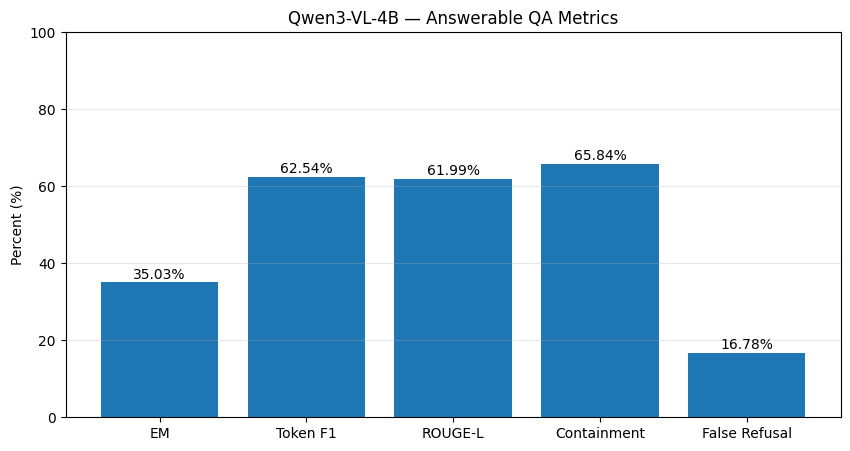

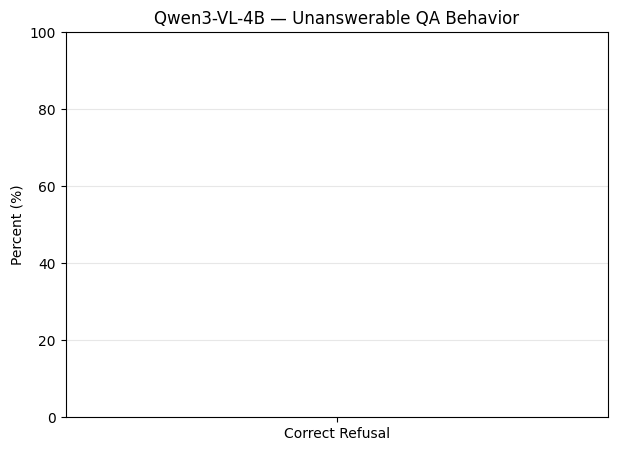

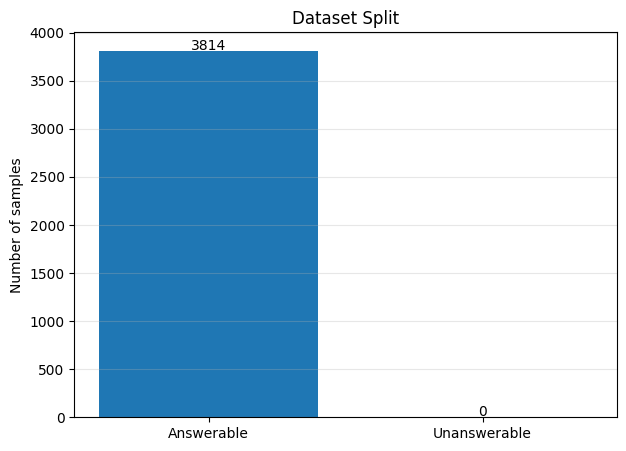

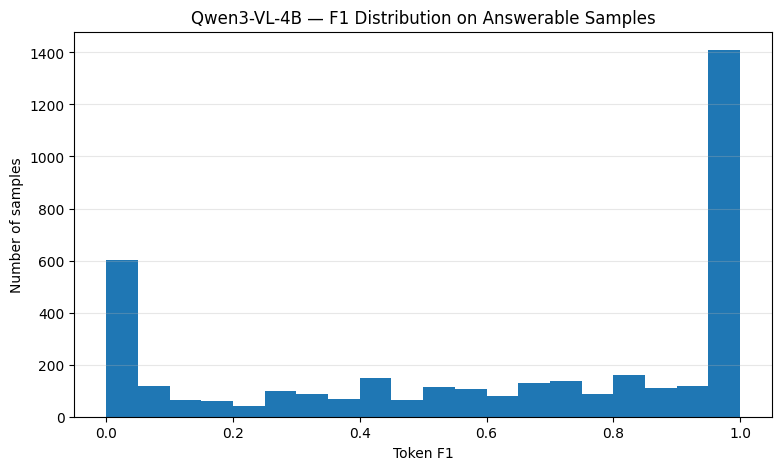


✅ Qwen fixed benchmark results saved to:
/home/rtx5070tiadmin/FPT_Exam_Product_Support/Exam_AssistAI/benchmark_outputs/qwen3_vl_4b_finetuned(on_domain)_viquad_val_20260620_222541


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 │ 💾 SAVE RESULTS + CHARTS — QWEN FIXED BENCHMARK
# ─────────────────────────────────────────────────────────────────────────────
import json
import matplotlib.pyplot as plt

results_jsonl = OUTPUT_DIR / "qwen_predictions_fixed_metrics.jsonl"
results_csv = OUTPUT_DIR / "qwen_predictions_fixed_metrics.csv"
summary_csv = OUTPUT_DIR / "qwen_summary_fixed_metrics.csv"
summary_json = OUTPUT_DIR / "qwen_summary_fixed_metrics.json"

with open(results_jsonl, "w", encoding="utf-8") as f:
    for row in rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

df.to_csv(results_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved fixed metrics:")
print(results_jsonl)
print(results_csv)
print(summary_csv)
print(summary_json)

# Chart 1: Answerable QA metrics
metric_names = ["EM", "Token F1", "ROUGE-L", "Containment", "False Refusal"]
metric_values = [
    summary["answerable_em"],
    summary["answerable_f1"],
    summary["answerable_rouge_l"],
    summary["answerable_containment"],
    summary["false_refusal_rate_answerable"]
]

plt.figure(figsize=(10, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title("Qwen3-VL-4B — Answerable QA Metrics")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

chart_path = OUTPUT_DIR / "qwen_answerable_metrics.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 2: Unanswerable behavior
metric_names = ["Correct Refusal", "Hallucination"]
metric_values = [
    summary["correct_refusal_rate_unanswerable"],
    summary["hallucination_rate_unanswerable"]
]

plt.figure(figsize=(7, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title("Qwen3-VL-4B — Unanswerable QA Behavior")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

chart_path = OUTPUT_DIR / "qwen_unanswerable_behavior.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 3: Dataset split
split_names = ["Answerable", "Unanswerable"]
split_values = [
    summary["answerable_samples"],
    summary["unanswerable_samples"]
]

plt.figure(figsize=(7, 5))
plt.bar(split_names, split_values)
plt.ylabel("Number of samples")
plt.title("Dataset Split")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(split_values):
    plt.text(i, v + 10, str(v), ha="center")

chart_path = OUTPUT_DIR / "dataset_split.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 4: F1 distribution on answerable only
plt.figure(figsize=(9, 5))
plt.hist(answerable_df["f1"], bins=20)
plt.xlabel("Token F1")
plt.ylabel("Number of samples")
plt.title("Qwen3-VL-4B — F1 Distribution on Answerable Samples")
plt.grid(axis="y", alpha=0.3)

chart_path = OUTPUT_DIR / "qwen_answerable_f1_distribution.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("\n✅ Qwen fixed benchmark results saved to:")
print(OUTPUT_DIR.resolve())

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 │ 📝 SAVE QWEN FIXED BENCHMARK REPORT
# ─────────────────────────────────────────────────────────────────────────────

report_path = OUTPUT_DIR / "qwen_benchmark_report_fixed_metrics.md"

report = f"""# Benchmark Report — Qwen3-VL-4B-Instruct Baseline

## Model

`{MODEL_NAME}`

## Dataset

`{DATASET_PATH}`

Number of samples: **{len(df)}**

- Answerable samples: **{summary["answerable_samples"]}**
- Unanswerable samples: **{summary["unanswerable_samples"]}**

## Main Results

### Answerable QA

| Metric | Value |
|---|---:|
| Answerable EM | {summary["answerable_em"]:.2f}% |
| Answerable Token F1 | {summary["answerable_f1"]:.2f}% |
| Answerable ROUGE-L | {summary["answerable_rouge_l"]:.2f}% |
| Containment Accuracy | {summary["answerable_containment"]:.2f}% |
| False Refusal Rate | {summary["false_refusal_rate_answerable"]:.2f}% |

### Unanswerable QA

| Metric | Value |
|---|---:|
| Correct Refusal Rate | {summary["correct_refusal_rate_unanswerable"]:.2f}% |
| Hallucination Rate on Unanswerable | {summary["hallucination_rate_unanswerable"]:.2f}% |

### Overall

| Metric | Value |
|---|---:|
| Overall EM | {summary["overall_em"]:.2f}% |
| Overall Token F1 | {summary["overall_f1"]:.2f}% |
| Overall ROUGE-L | {summary["overall_rouge_l"]:.2f}% |
| Average Latency | {summary["avg_latency_sec"]:.4f} sec/sample |
| Throughput | {summary["throughput_samples_per_sec"]:.2f} samples/sec |

## Interpretation

This benchmark follows a SQuAD2.0 / ViQuAD2.0-style evaluation because the dataset contains both answerable and unanswerable questions.

For answerable samples, EM, Token F1, ROUGE-L, and Containment Accuracy measure answer quality. Containment Accuracy is useful when the model generates a complete sentence while the gold answer is a short span.

For unanswerable samples, Correct Refusal Rate measures whether the model correctly refuses to answer when the context does not contain the answer. Hallucination Rate measures cases where the model produces an answer despite the gold label being unanswerable.

## Output Files

- `qwen_predictions_fixed_metrics.jsonl`
- `qwen_predictions_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.json`
- `qwen_answerable_metrics.png`
- `qwen_unanswerable_behavior.png`
- `dataset_split.png`
- `qwen_answerable_f1_distribution.png`
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("✅ Qwen fixed report saved:")
print(report_path.resolve())

✅ Qwen fixed report saved:
/home/rtx5070tiadmin/FPT_Exam_Product_Support/Exam_AssistAI/benchmark_outputs/qwen3_vl_4b_finetuned(on_domain)_viquad_val_20260620_222541/qwen_benchmark_report_fixed_metrics.md


In [7]:
print(prompts[0])
print(predictions[0])

<|im_start|>system
Bạn là trợ lý hỗ trợ giám thị thi tại Đại học FPT. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Nếu không tìm thấy thông tin trong tài liệu, hãy trả lời: 'Tôi không tìm thấy thông tin trong tài liệu'.<|im_end|>
<|im_start|>user
Ngữ cảnh: Paris nằm ở điểm gặp nhau của các hành trình thương mại đường bộ và đường sông, và là trung tâm của một vùng nông nghiệp giàu có. Vào thế kỷ 10, Paris đã là một trong những thành phố chính của Pháp cùng các cung điện hoàng gia, các tu viện và nhà thờ. Từ thế kỷ 12, Paris trở thành một trong những trung tâm của châu Âu về giáo dục và nghệ thuật. Thế kỷ 14, Paris là thành phố quan trọng bậc nhất của Cơ Đốc giáo và trong các thế kỷ 16, 17, đây là nơi diễn ra Cách mạng Pháp cùng nhiều sự kiện lịch sử quan trọng của Pháp và châu Âu. Đến thế kỷ 19 và 20, thành phố trở thành một trong những trung tâm văn hóa của thế giới, thủ đô của nghệ thuật và giải trí.

Câu hỏi: Paris đạt được thành quả gì sau khoảng 4 thế kỷ tính từ ngày Cách mạng Pháp

In [8]:
df["gold_len_words"].describe()
df["pred_len_words"].describe()
low_f1 = df.sort_values("f1").head(20)

for _, row in low_f1.iterrows():
    print("="*20)
    print("QUESTION:", row["question"])
    print("GOLD    :", row["gold_answer"])
    print("PRED    :", row["prediction"])
    print("F1      :", row["f1"])

QUESTION: Khi nào dự án tiêm vắc-xin miễn phí cho các nước đang phát triển được triển khai?
GOLD    : tháng 2 năm 2007
PRED    : Tôi không tìm thấy thông tin trong tài liệu.
F1      : 0.0
QUESTION: Trong cuộc phản ứng chiến tranh của Atal thì đã có bao nhiêu người Pháp thiệt mạng?
GOLD    : tôi không tìm thấy thông tin trong tài liệu
PRED    : 200 người Pháp thiệt mạng.
F1      : 0.0
QUESTION: Vào năm 1878 thì số lượng người Kanak là bao nhiêu?
GOLD    : tôi không tìm thấy thông tin trong tài liệu
PRED    : 60.000.
F1      : 0.0
QUESTION: Farley đã chấp thuận những hành động gì giúp phổ biến môn "sưu tầm tem"?
GOLD    : tôi không tìm thấy thông tin trong tài liệu
PRED    : Farley đã gia tăng con số phát hành tem kỷ niệm hàng năm và tạo ra nhiều bộ tem khác, giúp phổ biến rộng rãi hơn môn sưu tầm tem.
F1      : 0.0
QUESTION: Trong năm 1960, Mitterrand đã có bài phát biểu nổi tiếng nào?
GOLD    : La Baule
PRED    : Tôi không tìm thấy thông tin trong tài liệu.
F1      : 0.0
QUESTION: Cái 

In [9]:
refusal_gold = 0

for s in samples:
    gold = s["gold_answer"].lower()

    if "tôi không tìm thấy thông tin" in gold:
        refusal_gold += 1

print("Unanswerable samples:", refusal_gold)
print("Answerable samples:", len(samples)-refusal_gold)
print("Refusal ratio:", refusal_gold/len(samples)*100)

Unanswerable samples: 1161
Answerable samples: 2653
Refusal ratio: 30.440482433141057
